# 🚗 Ford Car Price — EDA & Linear Regression
## Dataset: Kaggle Ford Car Price Dataset
## Goal: Predict Ford car prices using Machine Learning

## 📚 Step 1: Import Libraries

In [515]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import statistics

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler

print("Library imported")
import warnings
warnings.filterwarnings('ignore')



Library imported


## 📦 Step 2: Load Data

In [516]:
df = pd.read_csv("ford.csv")

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [517]:
df.tail()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2
17965,Focus,2015,8299,Manual,5007,Petrol,22,57.7,1.0


### 📐 Dataset Shape
- Checking how many rows and columns exist
- Rows = number of cars
- Columns = number of features per car

In [518]:
print(df.dtypes)

model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object


### 🔍 Checking Data Types
- Identifying numeric and categorical columns
- Numeric columns: year, price, mileage, tax, mpg, engineSize
- Categorical columns: model, transmission, fuelType

In [519]:
df.shape

(17966, 9)

### ℹ️ Dataset Info
- Checking data types of each column
- Checking for null/missing values
- All 17,966 rows are non-null — no missing values found!

In [520]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


### 📊 Statistical Summary
- Checking min, max, mean, median for all numeric columns
- Key findings:
  - Year 2060 found — impossible value, data error!
  - Price ranges from £495 to £54,995
  - Mileage ranges from 1 to 177,644 miles
  - Engine size 0.0 exists — needs investigation

In [521]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,17966.0,2016.866470,2.050336,1996.0,2016.0,2017.0,2018.0,2060.0
price,17966.0,12279.534844,4741.343657,495.0,8999.0,11291.0,15299.0,54995.0
mileage,17966.0,23362.608761,19472.054349,1.0,9987.0,18242.5,31060.0,177644.0
tax,17966.0,113.329456,62.012456,0.0,30.0,145.0,145.0,580.0
mpg,17966.0,57.906980,10.125696,20.8,52.3,58.9,65.7,201.8
engineSize,17966.0,1.350807,0.432367,0.0,1.0,1.2,1.5,5.0


### 📊 Categorical Columns Analysis
- Checking unique categories in model, transmission and fuelType
- Found space issue in Focus model name — fixed using str.strip()

In [522]:
print(df['model'].value_counts())
print("---")
print(df['transmission'].value_counts())
print("---")
print(df['fuelType'].value_counts())

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64
---
transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64
---
fuelType
Petrol      12179
Diesel       5762
Hybrid         22
Electric        2
Other           1
Name: count, dtype: i

In [523]:
df["model"] = df["model"].str.strip()

In [524]:
df["model"].value_counts()

model
Fiesta                   6557
Focus                    4589
Kuga                     2225
EcoSport                 1143
C-MAX                     543
Ka+                       531
Mondeo                    526
B-MAX                     355
S-MAX                     296
Grand C-MAX               247
Galaxy                    228
Edge                      208
KA                        199
Puma                       80
Tourneo Custom             69
Grand Tourneo Connect      59
Mustang                    57
Tourneo Connect            33
Fusion                     16
Streetka                    2
Ranger                      1
Escort                      1
Transit Tourneo             1
Name: count, dtype: int64

In [525]:
print(df[df['year'] > 2020]['year'].value_counts())

year
2060    1
Name: count, dtype: int64


### 🧹 Removing Invalid Year
- Found year 2060 — impossible value in 2020 dataset
- Removing 1 row with year > 2020

In [526]:
df = df[df['year'] <= 2020]
print("New shape:", df.shape)

New shape: (17965, 9)


In [527]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 154


### 🧹 Removing Duplicate Rows
- Found 154 duplicate rows
- Removing all duplicates

In [528]:
df = df.drop_duplicates()
print("New shape:", df.shape)

New shape: (17811, 9)


In [529]:
df[df["engineSize"]==0][["fuelType"]].value_counts()

fuelType
Petrol      45
Diesel       5
Hybrid       1
Name: count, dtype: int64

### 🧹 Removing Invalid Engine Size
- Engine size 0.0 found in Petrol and Diesel cars — impossible!
- Only valid for Electric/Hybrid
- Removing 51 rows with engine size 0.0

In [530]:
df = df[df['engineSize'] != 0]
print("New shape:", df.shape)

New shape: (17760, 9)


In [531]:
print(df.nunique())

model              23
year               22
price            3491
transmission        3
mileage         13523
fuelType            5
tax                36
mpg                90
engineSize         15
dtype: int64


### 🔍 Outlier Detection
- Using IQR method to detect outliers
- Checking all numeric columns
- All outliers found are genuine real world values — kept!

In [532]:
def check_Outlier(data):

    outlier = []
    Q1 =  np.percentile(data,25)
    Q3 = np.percentile(data,75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

 
    for x in data:
        if  x < lower_fence or upper_fence < x:

            outlier.append(x)

    

    return outlier

In [533]:

# numeric_cols = [["year","price","mileage","tax","mpg"]]
lst = check_Outlier(df["price"])

In [534]:
len(lst)

282

In [535]:
Q1 = np.percentile(df["price"], 25)
Q3 = np.percentile(df["price"], 75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 8999.0
Q3: 15295.0
IQR: 6296.0
Lower fence: -445.0
Upper fence: 24739.0


In [536]:
outliers_df = df[df['price'] > 24739]
print(outliers_df['model'].value_counts())

model
Focus             74
Mustang           56
Edge              51
S-MAX             30
Kuga              26
Galaxy            17
Tourneo Custom    15
Mondeo             8
Puma               4
Fiesta             1
Name: count, dtype: int64


In [537]:
lst2 = check_Outlier(df["mileage"])
print(len(lst2))

862


In [538]:
Q1 = np.percentile(df["mileage"], 25)
Q3 = np.percentile(df["mileage"], 75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

Q1: 10000.0
Q3: 31107.0
IQR: 21107.0
Lower fence: -21660.5
Upper fence: 62767.5


In [539]:
for col in ['year', 'tax', 'mpg', 'engineSize']:
    lst = check_Outlier(df[col])
    print(f"{col}: {len(lst)} outliers")

year: 497 outliers
tax: 20 outliers
mpg: 216 outliers
engineSize: 139 outliers


In [540]:
for col in ['year', 'tax', 'mpg', 'engineSize']:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    print(f"{col}: Lower={lower_fence}, Upper={upper_fence}")

year: Lower=2013.0, Upper=2021.0
tax: Lower=-142.5, Upper=317.5
mpg: Lower=32.19999999999999, Upper=85.80000000000001
engineSize: Lower=0.25, Upper=2.25


## 📊 Phase 4 — Univariate Analysis
- Analyzing each column individually
- Looking at distribution, mean and median

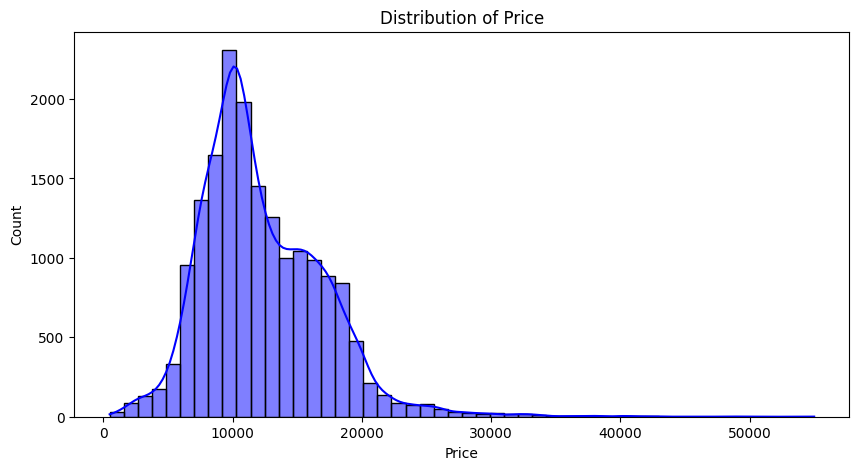

In [541]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, color='blue',kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [542]:
print("Mean price:", df['price'].mean())
print("Median price:", df['price'].median())

Mean price: 12271.296565315315
Median price: 11290.0


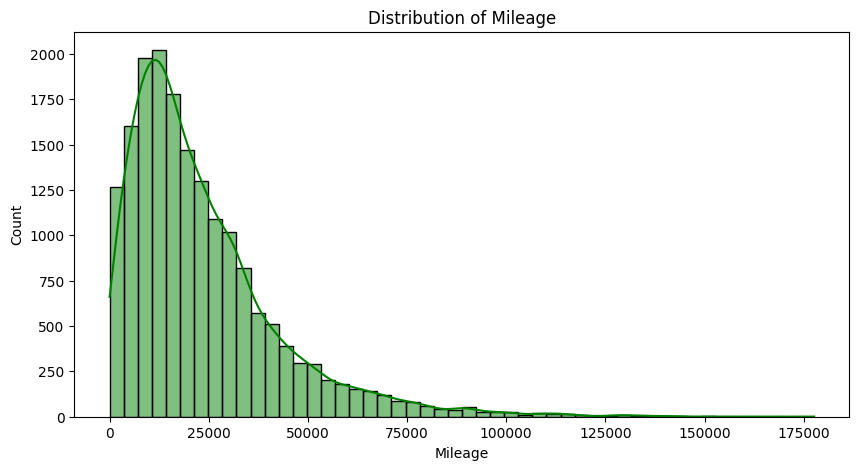

In [543]:
plt.figure(figsize=(10,5))
sns.histplot(df['mileage'], bins=50, color='green',kde=True)
plt.title('Distribution of Mileage')
plt.xlabel('Mileage')
plt.ylabel('Count')
plt.show()

In [544]:
print("Mean mileage:", df['mileage'].mean())
print("Median mileage:", df['mileage'].median())

Mean mileage: 23390.261486486488
Median mileage: 18291.0


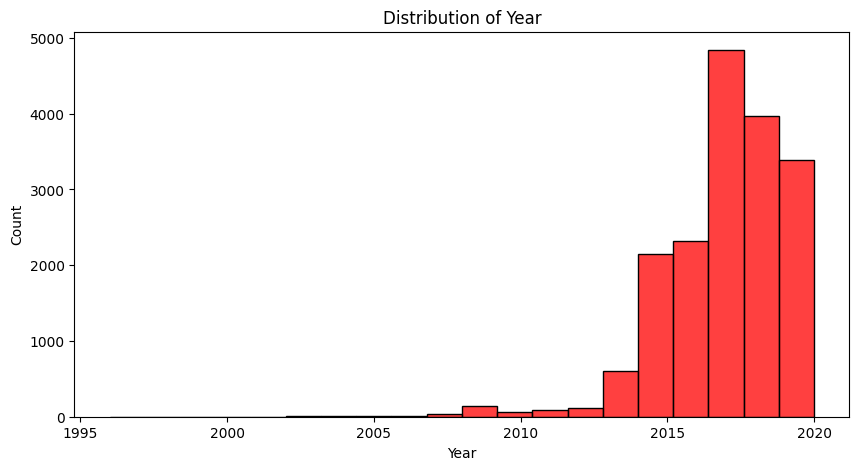

In [545]:
plt.figure(figsize=(10,5))
sns.histplot(df['year'], bins=20, color='red')
plt.title('Distribution of Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

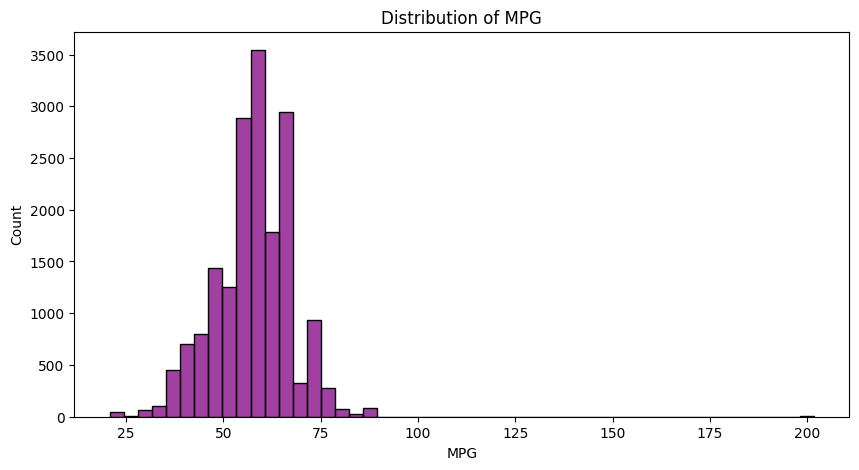

In [546]:
plt.figure(figsize=(10,5))
sns.histplot(df['mpg'], bins=50, color='purple')
plt.title('Distribution of MPG')
plt.xlabel('MPG')
plt.ylabel('Count')
plt.show()

In [547]:
print("Mean MPG:", df['mpg'].mean())
print("Median MPG:", df['mpg'].median())

Mean MPG: 57.912443693693696
Median MPG: 58.9


Text(0, 0.5, 'Count')

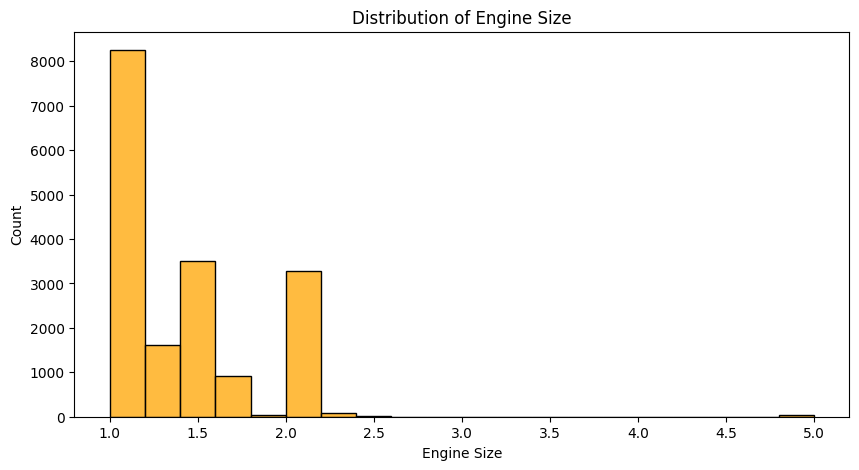

In [548]:
plt.figure(figsize=(10,5))
sns.histplot(df['engineSize'], bins=20, color='orange')
plt.title('Distribution of Engine Size')
plt.xlabel('Engine Size')
plt.ylabel('Count')

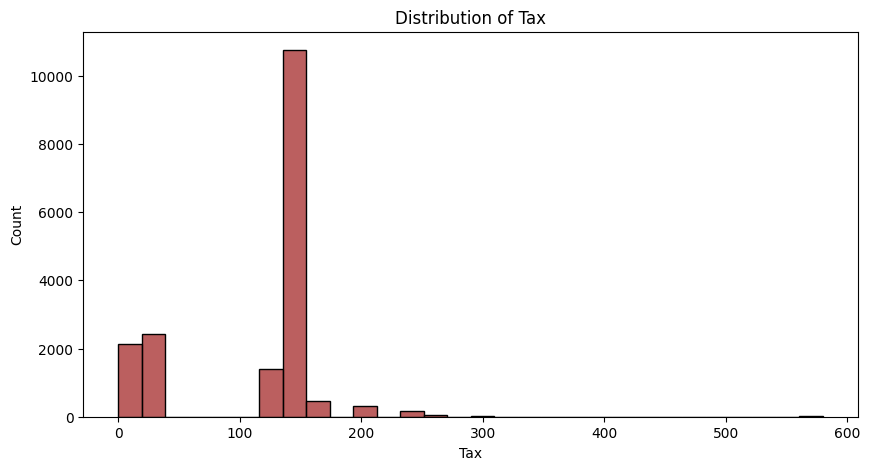

In [549]:
plt.figure(figsize=(10,5))
sns.histplot(df['tax'], bins=30, color='brown')
plt.title('Distribution of Tax')
plt.xlabel('Tax')
plt.ylabel('Count')
plt.show()

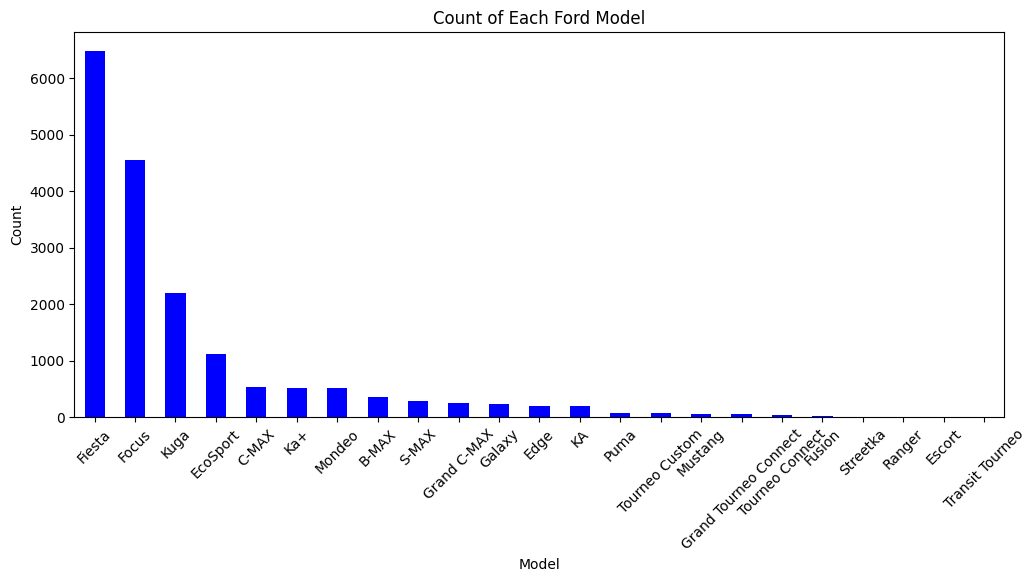

In [550]:
plt.figure(figsize=(12,5))
df['model'].value_counts().plot(kind='bar', color='blue')
plt.title('Count of Each Ford Model')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

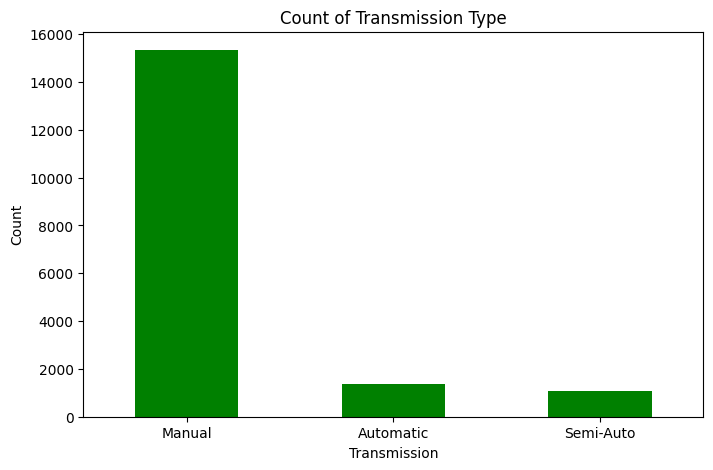

In [551]:
plt.figure(figsize=(8,5))
df['transmission'].value_counts().plot(kind='bar', color='green')
plt.title('Count of Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

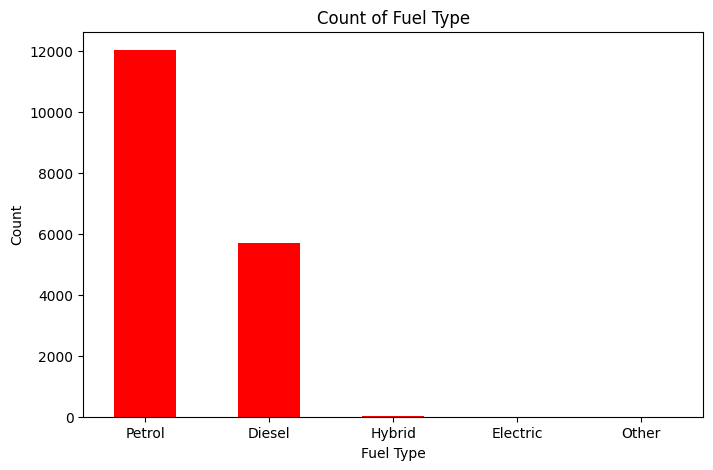

In [552]:
plt.figure(figsize=(8,5))
df['fuelType'].value_counts().plot(kind='bar', color='red')
plt.title('Count of Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 🔍 Phase 5 — Bivariate Analysis
- Comparing each feature against price
- Finding which features affect price

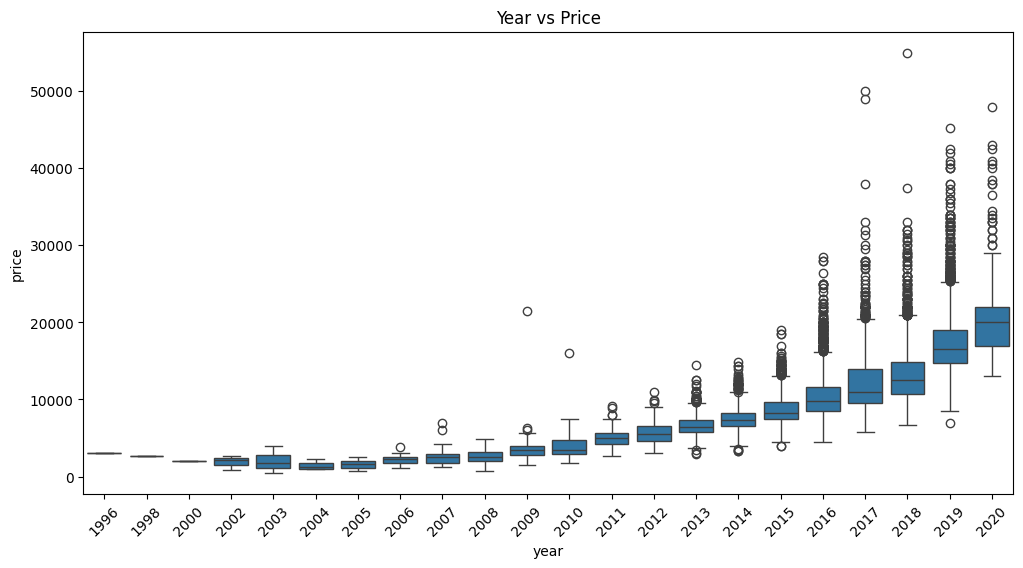

In [553]:
plt.figure(figsize=(12,6))
sns.boxplot(x='year', y='price', data=df)
plt.title('Year vs Price')
plt.xticks(rotation=45)
plt.show()

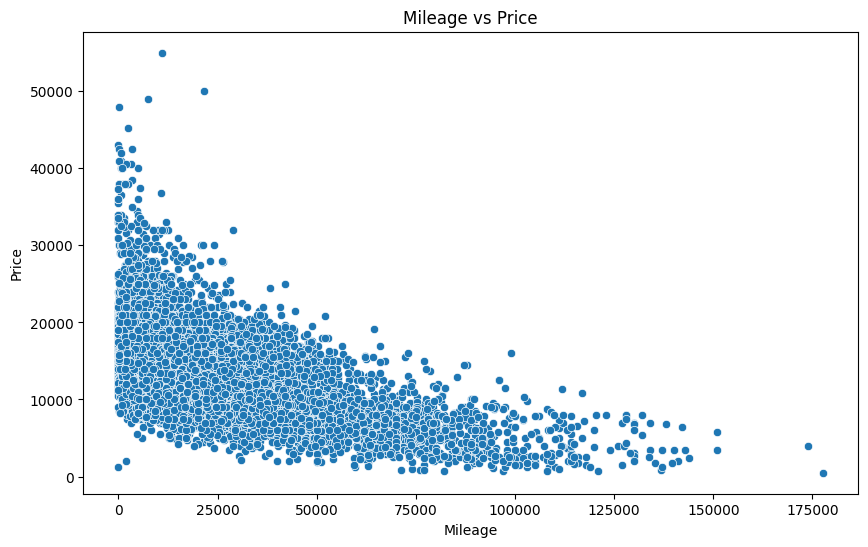

In [554]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='mileage', y='price', data=df)
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

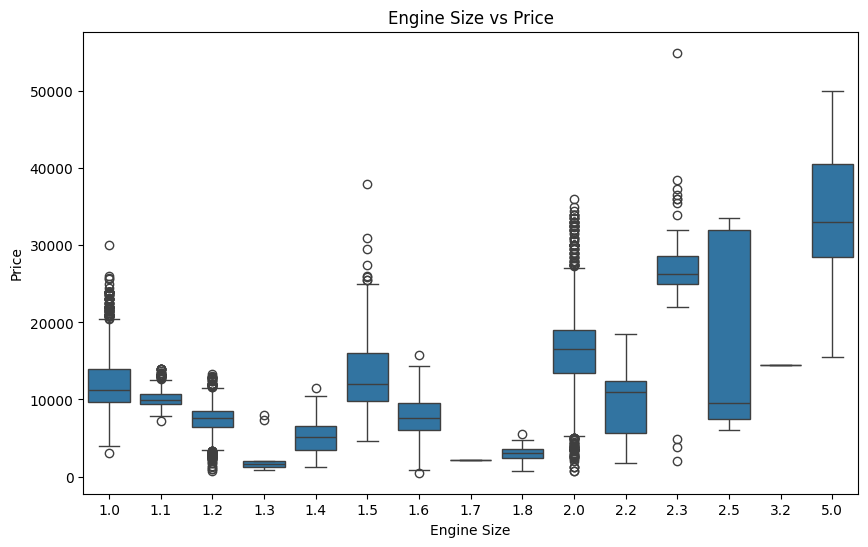

In [555]:
plt.figure(figsize=(10,6))
sns.boxplot(x='engineSize', y='price', data=df)
plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

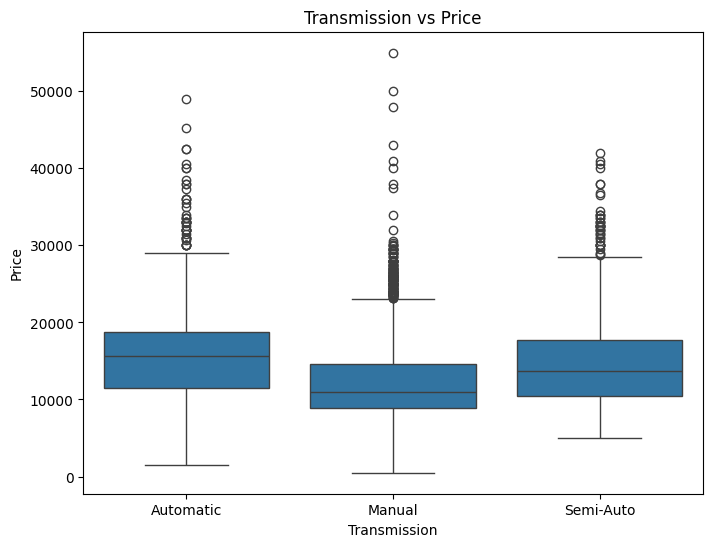

In [556]:
plt.figure(figsize=(8,6))
sns.boxplot(x='transmission', y='price', data=df)
plt.title('Transmission vs Price')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.show()

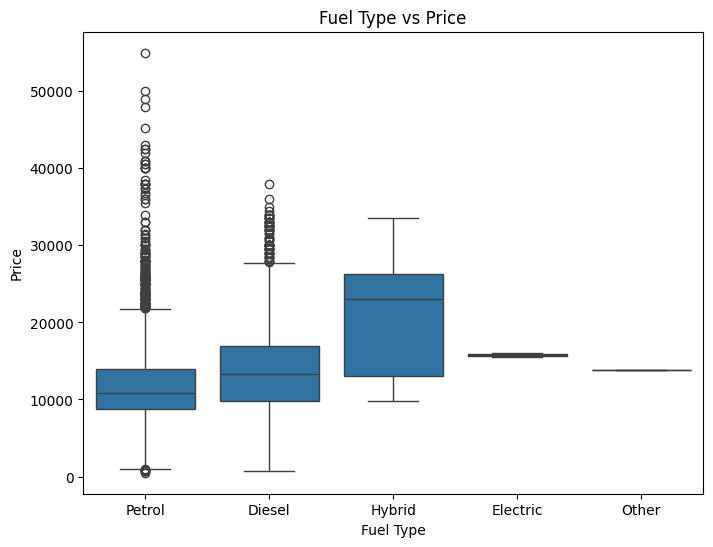

In [557]:
plt.figure(figsize=(8,6))
sns.boxplot(x='fuelType', y='price', data=df)
plt.title('Fuel Type vs Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.show()

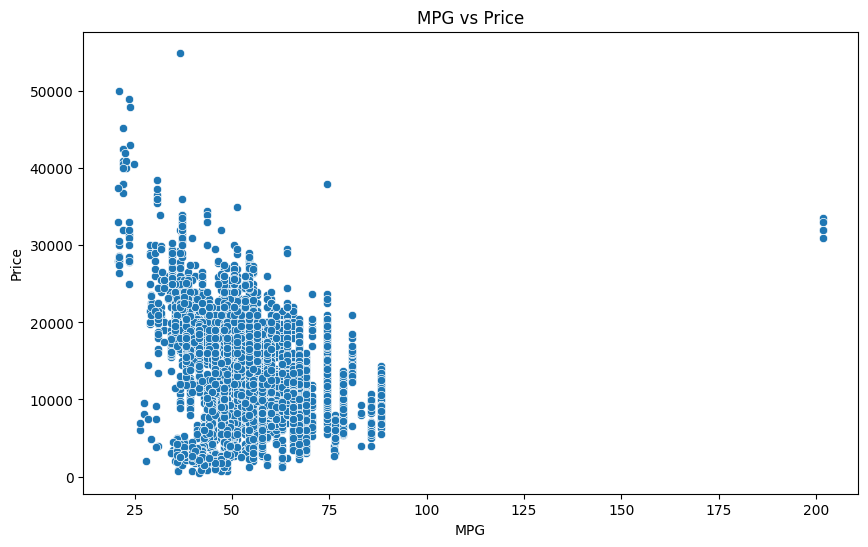

In [558]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='mpg', y='price', data=df)
plt.title('MPG vs Price')
plt.xlabel('MPG')
plt.ylabel('Price')
plt.show()

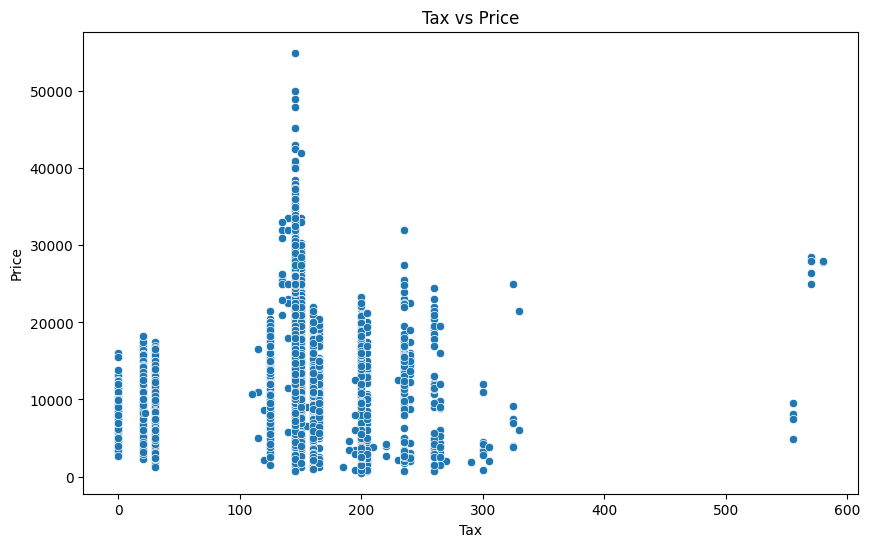

In [559]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='tax', y='price', data=df)
plt.title('Tax vs Price')
plt.xlabel('Tax')
plt.ylabel('Price')
plt.show()

## 🔬 Phase 6 — Multivariate Analysis
- Comparing 3 columns together
- Finding combined effects on price

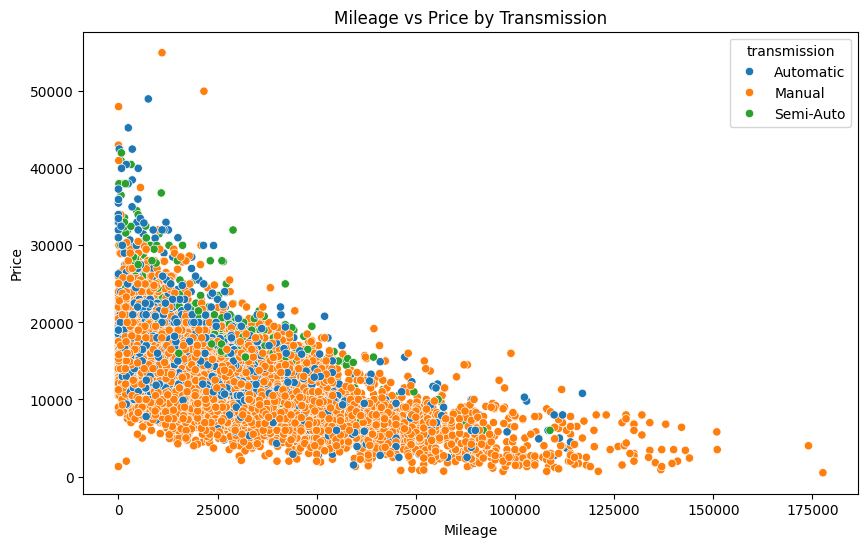

In [560]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='mileage', y='price', hue='transmission', data=df)
plt.title('Mileage vs Price by Transmission')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

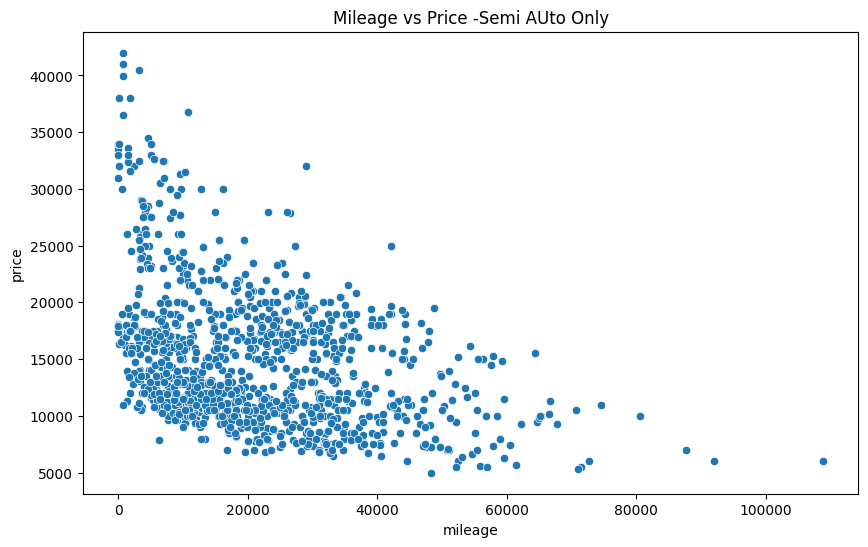

In [561]:
manual = df[df['transmission'] == 'Semi-Auto']
plt.figure(figsize=(10,6))
sns.scatterplot(x='mileage', y='price', data=manual)
plt.title('Mileage vs Price -Semi AUto Only')
plt.show()

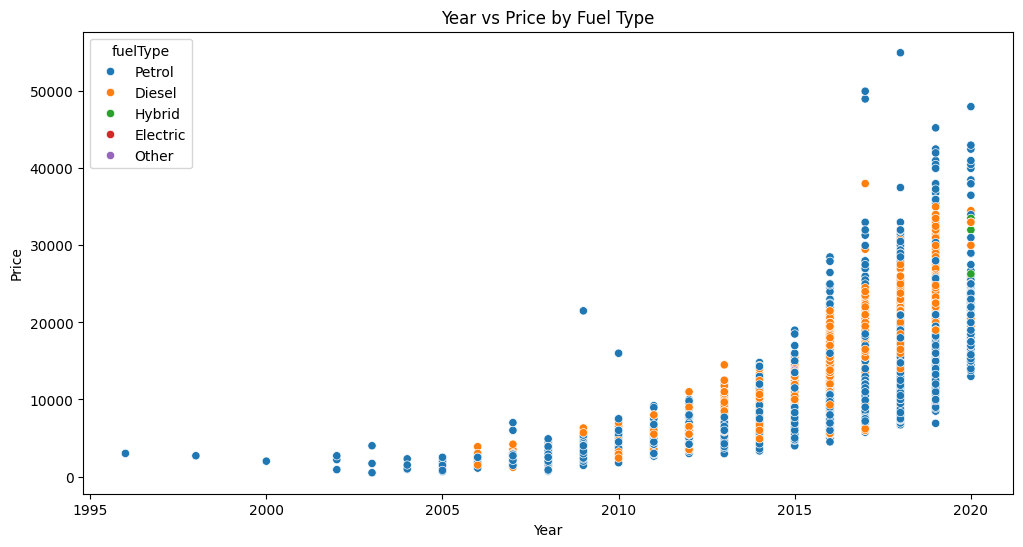

In [562]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='year', y='price', hue='fuelType', data=df)
plt.title('Year vs Price by Fuel Type')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

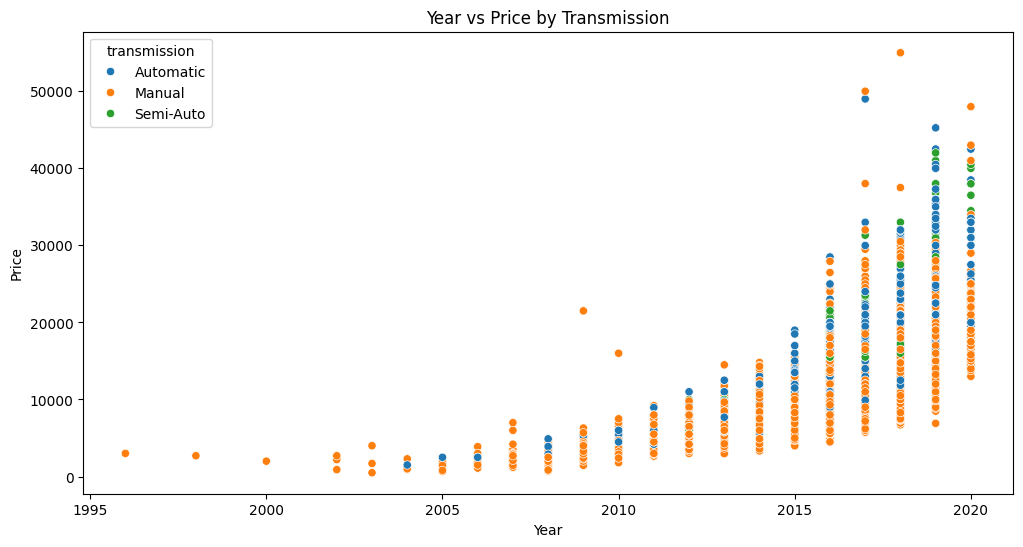

In [563]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='year', y='price', hue='transmission', data=df)
plt.title('Year vs Price by Transmission')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

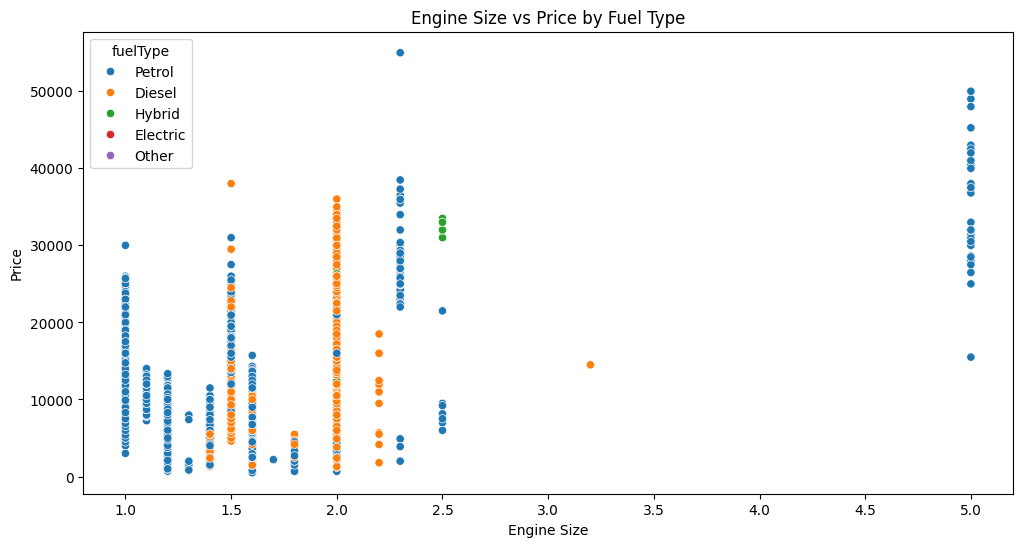

In [564]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='engineSize', y='price', hue='fuelType', data=df)
plt.title('Engine Size vs Price by Fuel Type')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

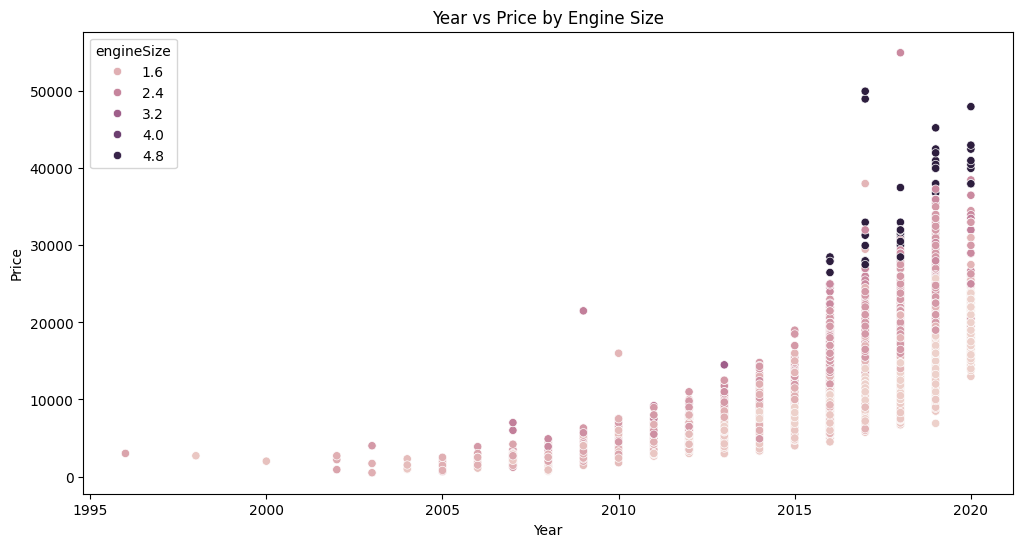

In [565]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='year', y='price', hue='engineSize', data=df)
plt.title('Year vs Price by Engine Size')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

In [566]:
correlation = df.corr(numeric_only=True)
# plt.figure(figsize=(10,8))
# sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
# plt.title('Correlation Heatmap')
# plt.show()
correlation

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.645553,-0.719459,0.298729,-0.019303,-0.139539
price,0.645553,1.000000,-0.530648,0.406303,-0.346463,0.416801
mileage,-0.719459,-0.530648,1.000000,-0.257229,0.117155,0.216255
tax,0.298729,0.406303,-0.257229,1.000000,-0.502518,0.187623
mpg,-0.019303,-0.346463,0.117155,-0.502518,1.000000,-0.267240
engineSize,-0.139539,0.416801,0.216255,0.187623,-0.267240,1.000000


## 🔢 Aggregation — Confirming With Numbers
- Confirming visual findings with actual numbers
- Grouping by category and calculating mean price

In [567]:
print(df.groupby('transmission')['price'].mean().sort_values(ascending=False))

transmission
Automatic    15720.056338
Semi-Auto    14897.974884
Manual       11783.812467
Name: price, dtype: float64


In [568]:
print(df.groupby('fuelType')['price'].mean().sort_values(ascending=False))

fuelType
Hybrid      22061.000000
Electric    15737.500000
Other       13800.000000
Diesel      13644.633047
Petrol      11602.959535
Name: price, dtype: float64


In [569]:
print(df.groupby('model')['price'].mean().sort_values(ascending=False))

model
Mustang                  34631.263158
Edge                     22710.165854
Puma                     21394.948718
Tourneo Custom           21165.985507
Galaxy                   17848.669604
S-MAX                    17655.401361
Kuga                     15817.723154
Grand Tourneo Connect    14765.456140
Ranger                   14495.000000
Tourneo Connect          13862.406250
Focus                    13176.990319
EcoSport                 12468.428954
Transit Tourneo          12450.000000
Mondeo                   12272.510763
Grand C-MAX              10881.574899
Fiesta                   10189.513947
C-MAX                     9913.503690
Ka+                       8685.175337
B-MAX                     8271.691429
KA                        5085.172775
Escort                    3000.000000
Fusion                    2555.812500
Streetka                  1924.500000
Name: price, dtype: float64


In [570]:
print(df.groupby('year')['price'].mean().sort_values(ascending=False))

year
2020    20858.776892
2019    17179.071588
2018    13152.662295
2017    11971.210994
2016    10662.179421
2015     8785.191111
2014     7538.359649
2013     6701.337748
2012     5680.930435
2011     5022.478723
2010     4058.253731
2009     3719.725275
1996     3000.000000
1998     2699.000000
2008     2613.250000
2007     2603.562500
2006     2202.615385
2003     2063.000000
2000     1995.000000
2002     1928.333333
2005     1593.000000
2004     1436.000000
Name: price, dtype: float64


In [571]:
print(df.groupby('engineSize')['price'].mean().sort_values(ascending=False))

engineSize
5.0    34967.800000
2.3    26791.887500
2.5    18292.615385
2.0    16272.229148
3.2    14495.000000
1.5    12862.905983
1.0    11885.245391
2.2    10400.923077
1.1    10222.196364
1.6     7704.301743
1.2     7427.238066
1.4     5226.630631
1.8     2961.171429
1.3     2493.666667
1.7     2195.000000
Name: price, dtype: float64


In [572]:
print(df.groupby(pd.cut(df['mileage'], bins=5))['price'].mean())

mileage
(-176.643, 35529.6]     13176.620740
(35529.6, 71058.2]       9020.412937
(71058.2, 106586.8]      5807.385965
(106586.8, 142115.4]     4503.011236
(142115.4, 177644.0]     3263.166667
Name: price, dtype: float64


In [573]:
print(df.groupby(pd.cut(df['mpg'], bins=5))['price'].mean())

mpg
(20.619, 57.0]    13577.853146
(57.0, 93.2]      11247.815982
(93.2, 129.4]              NaN
(129.4, 165.6]             NaN
(165.6, 201.8]    32297.200000
Name: price, dtype: float64


In [574]:
print(df.groupby(pd.cut(df['tax'], bins=5))['price'].mean())

tax
(-0.58, 116.0]     8769.079086
(116.0, 232.0]    13499.312659
(232.0, 348.0]    11931.253219
(348.0, 464.0]             NaN
(464.0, 580.0]    20817.250000
Name: price, dtype: float64


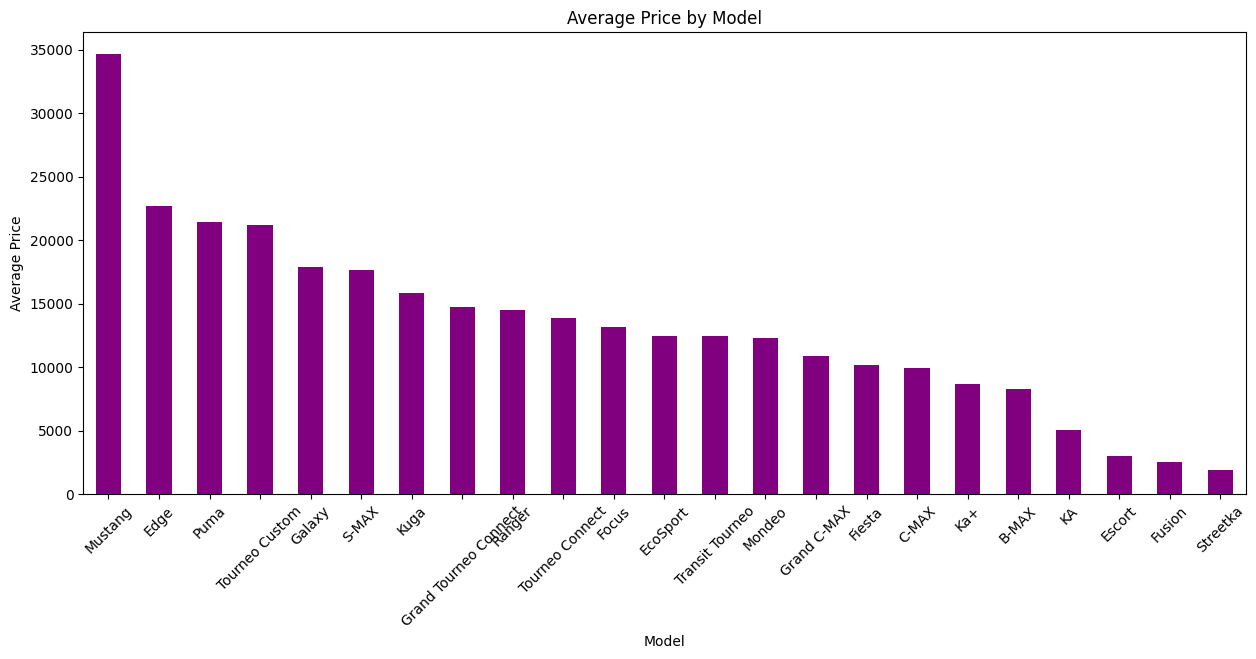

In [575]:
plt.figure(figsize=(15,6))
df.groupby('model')['price'].mean().sort_values(ascending=False).plot(kind='bar', color='purple')
plt.title('Average Price by Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

## ⚙️ Phase 7 — Feature Engineering
### Grouping Rare Models
- Models below 50 cars grouped into Other
- Prevents ML model from learning from too few examples

In [576]:
df["model"].value_counts()

model
Fiesta                   6489
Focus                    4545
Kuga                     2207
EcoSport                 1119
C-MAX                     542
Ka+                       519
Mondeo                    511
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        191
Puma                       78
Tourneo Custom             69
Mustang                    57
Grand Tourneo Connect      57
Tourneo Connect            32
Fusion                     16
Streetka                    2
Ranger                      1
Escort                      1
Transit Tourneo             1
Name: count, dtype: int64

<!-- Feature Engineering -->

In [577]:
# Find models with less than 50 cars
threshold = 50
model_counts = df['model'].value_counts()
rare_models = model_counts[model_counts < threshold].index
print("Rare models to become Other:")
print(rare_models.tolist())

Rare models to become Other:
['Tourneo Connect', 'Fusion', 'Streetka', 'Ranger', 'Escort', 'Transit Tourneo']


In [578]:
threshold = 50
model_counts = df['model'].value_counts()
rare_models = model_counts[model_counts < threshold].index
df['model'] = df['model'].apply(lambda x: 'Other' if x in rare_models else x)
print(df['model'].value_counts())

model
Fiesta                   6489
Focus                    4545
Kuga                     2207
EcoSport                 1119
C-MAX                     542
Ka+                       519
Mondeo                    511
B-MAX                     350
S-MAX                     294
Grand C-MAX               247
Galaxy                    227
Edge                      205
KA                        191
Puma                       78
Tourneo Custom             69
Mustang                    57
Grand Tourneo Connect      57
Other                      53
Name: count, dtype: int64


### Encoding Categorical Columns
- Model → One Hot Encoding (no order)
- Transmission → Label Encoding (has price order)
- FuelType → One Hot Encoding (no order)
- Dropped Tax and MPG — weak relationship with price

In [579]:
df = pd.get_dummies(df, columns=['model'], drop_first=True,dtype=int)

In [580]:
df.head()

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,model_C-MAX,model_EcoSport,...,model_Grand Tourneo Connect,model_KA,model_Ka+,model_Kuga,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom
0,2017,12000,Automatic,15944,Petrol,150,57.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2018,14000,Manual,9083,Petrol,150,57.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017,13000,Manual,12456,Petrol,150,57.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2019,17500,Manual,10460,Petrol,145,40.3,1.5,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2019,16500,Automatic,1482,Petrol,145,48.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [581]:
df.tail()

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,model_C-MAX,model_EcoSport,...,model_Grand Tourneo Connect,model_KA,model_Ka+,model_Kuga,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom
17961,2017,8999,Manual,16700,Petrol,150,47.1,1.4,0,0,...,0,0,0,0,0,0,0,0,0,0
17962,2014,7499,Manual,40700,Petrol,30,57.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0
17963,2015,9999,Manual,7010,Diesel,20,67.3,1.6,0,0,...,0,0,0,0,0,0,0,0,0,0
17964,2018,8299,Manual,5007,Petrol,145,57.7,1.2,0,0,...,0,1,0,0,0,0,0,0,0,0
17965,2015,8299,Manual,5007,Petrol,22,57.7,1.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [582]:
le = LabelEncoder()

df["transmission"]= le.fit_transform(df["transmission"])

In [583]:
df["transmission"].value_counts()

transmission
1    15336
0     1349
2     1075
Name: count, dtype: int64

In [584]:
df = pd.get_dummies(df, columns=['fuelType'], drop_first=True,dtype=int)

In [585]:
df.head()

,year,price,transmission,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,...,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,0,15944,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,1,9083,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2017,13000,1,12456,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2019,17500,1,10460,145,40.3,1.5,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2019,16500,0,1482,145,48.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [586]:
df.head()

,year,price,transmission,mileage,tax,mpg,engineSize,model_C-MAX,model_EcoSport,model_Edge,...,model_Mondeo,model_Mustang,model_Other,model_Puma,model_S-MAX,model_Tourneo Custom,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,12000,0,15944,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2018,14000,1,9083,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,2017,13000,1,12456,150,57.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,2019,17500,1,10460,145,40.3,1.5,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2019,16500,0,1482,145,48.7,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


## 📐 Phase 8 — Log Transformation
- Price and Mileage are right skewed
- Log transformation makes distribution normal
- Required for Linear Regression

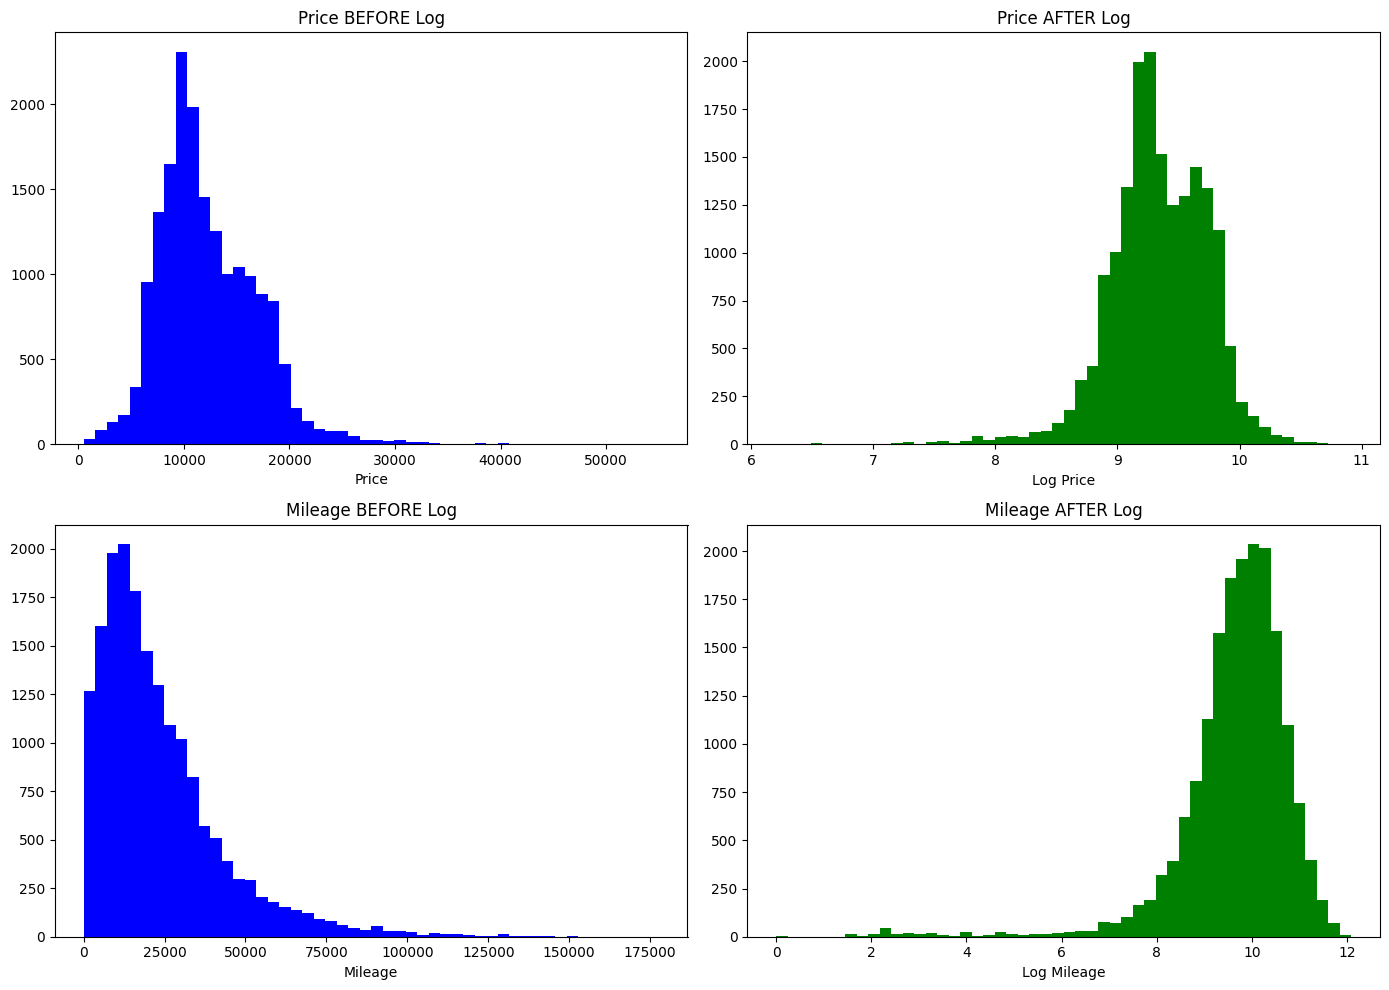

In [587]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Price Before
axes[0,0].hist(df['price'], bins=50, color='blue')
axes[0,0].set_title('Price BEFORE Log')
axes[0,0].set_xlabel('Price')

# Price After
axes[0,1].hist(np.log(df['price']), bins=50, color='green')
axes[0,1].set_title('Price AFTER Log')
axes[0,1].set_xlabel('Log Price')

# Mileage Before
axes[1,0].hist(df['mileage'], bins=50, color='blue')
axes[1,0].set_title('Mileage BEFORE Log')
axes[1,0].set_xlabel('Mileage')

# Mileage After
axes[1,1].hist(np.log(df['mileage']), bins=50, color='green')
axes[1,1].set_title('Mileage AFTER Log')
axes[1,1].set_xlabel('Log Mileage')

plt.tight_layout()
plt.show()

In [588]:
df["mileage"] = np.log(df["mileage"])

In [589]:
df["price"]=np.log(df["price"])

<Axes: xlabel='mileage', ylabel='Count'>

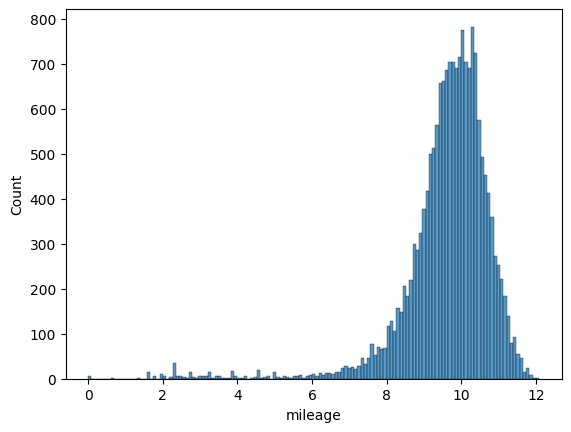

In [590]:
sns.histplot(df["mileage"])

## 📏 Phase 9 — Scaling
- Using StandardScaler for normally distributed data
- Scaling: year, mileage, engineSize, transmission

In [591]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['year', 'mileage', 'engineSize', 'transmission']

df[scale_cols] = scaler.fit_transform(df[scale_cols])
print("✅ Scaling done!")
print(df[scale_cols].head())

✅ Scaling done!
       year   mileage  engineSize  transmission
0  0.069705  0.031028   -0.830024     -2.667360
1  0.562916 -0.435891   -0.830024      0.041797
2  0.069705 -0.173837   -0.830024      0.041797
3  1.056126 -0.318759    0.340676      0.041797
4  1.056126 -1.940356   -0.830024     -2.667360


## ✂️ Phase 10 — Train Test Split
- X = All features except price (input)
- Y = Price column (what we predict!)
- 70% training, 30% testing
- random_state=42 ensures same split every time

In [592]:
X= df.drop(columns=["price"])
Y= df["price"]

### Splitting Data
- X_train: 12,432 cars for training
- X_test: 5,328 cars for testing
- Y_train: 12,432 actual prices for training
- Y_test: 5,328 actual prices for testing

In [593]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=42)

In [594]:
X_train.columns

Index(['year', 'transmission', 'mileage', 'tax', 'mpg', 'engineSize',
       'model_C-MAX', 'model_EcoSport', 'model_Edge', 'model_Fiesta',
       'model_Focus', 'model_Galaxy', 'model_Grand C-MAX',
       'model_Grand Tourneo Connect', 'model_KA', 'model_Ka+', 'model_Kuga',
       'model_Mondeo', 'model_Mustang', 'model_Other', 'model_Puma',
       'model_S-MAX', 'model_Tourneo Custom', 'fuelType_Electric',
       'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol'],
      dtype='object')

In [595]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

X_train: (12432, 27)
X_test: (5328, 27)
Y_train: (12432,)
Y_test: (5328,)


## 🤖 Phase 11 — Model Building
- Using Linear Regression
- Formula: Price = m1(year) + m2(mileage) + ... + C

In [596]:
model= LinearRegression()

In [597]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [598]:
Y_pred = model.predict(X_test)

print("✅ Predictions done!")
print("First 5 predicted prices:", Y_pred[:5])
print("First 5 real prices:", Y_test[:5].values)


✅ Predictions done!
First 5 predicted prices: [9.3469317  9.12377252 9.17873675 8.84458618 9.36270242]
First 5 real prices: [9.43348392 9.21034037 9.08591029 8.9226583  9.25894004]


In [599]:
print(f"Intercept :{model.intercept_}")
print(f"Slope : {model.coef_[0]}")

Intercept :9.265368360981
Slope : 0.28703393091998747


In [600]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
})
print(coefficients.sort_values('Coefficient', ascending=False))

                        Feature  Coefficient
8                    model_Edge     0.594311
11                 model_Galaxy     0.498324
22         model_Tourneo Custom     0.473994
21                  model_S-MAX     0.463082
25               fuelType_Other     0.356963
20                   model_Puma     0.335392
23            fuelType_Electric     0.334728
13  model_Grand Tourneo Connect     0.332538
16                   model_Kuga     0.314168
0                          year     0.287034
10                  model_Focus     0.189046
19                  model_Other     0.187608
24              fuelType_Hybrid     0.178319
12            model_Grand C-MAX     0.176383
5                    engineSize     0.116392
17                 model_Mondeo     0.113355
7                model_EcoSport     0.111801
26              fuelType_Petrol     0.096363
6                   model_C-MAX     0.093588
18                model_Mustang     0.033004
9                  model_Fiesta     0.027148
3         

## 📈 Phase 12 — Model Evaluation

### Metrics Used:
- **R2 Score** — How well model explains price variation
  - 1.0 = Perfect, 0.0 = Model learned nothing
  - Our score: 0.88 = Model explains 88% of price variation!
  
- **RMSE** — Average prediction error
  - Our score: 0.14 (in log scale)
  - Means model is off by ~15% on average in real price

### Results:
- R2 Score: 0.8808 ✅ Very Good!
- RMSE: 0.1418 ✅ Low error!

### Real vs Predicted Chart:
- Dots close to red line = accurate predictions
- Model struggles slightly with very old/cheap cars
- Model performs best for typical £8,000-£20,000 cars

In [601]:
from sklearn.metrics import r2_score, mean_squared_error

Y_pred = model.predict(X_test)

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.8824
RMSE: 0.1409


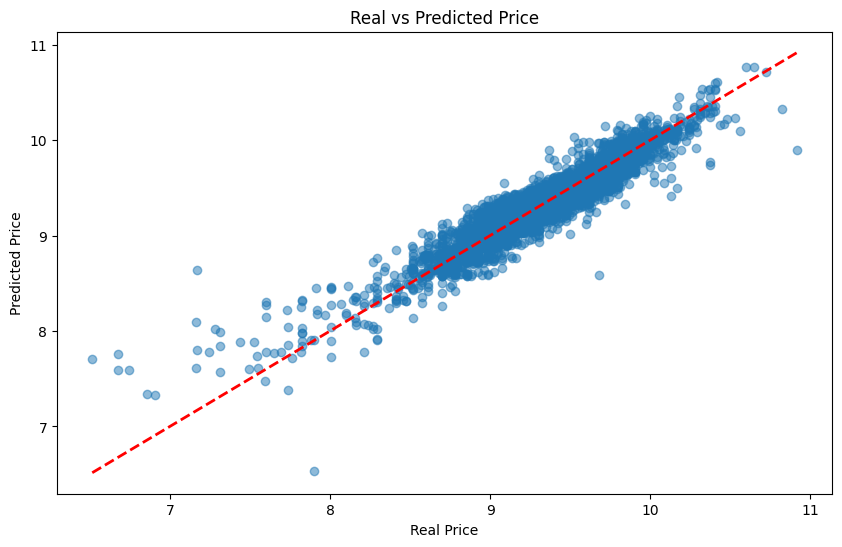

In [602]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], 
         [Y_test.min(), Y_test.max()], 
         'r--', linewidth=2)
plt.xlabel('Real Price')
plt.ylabel('Predicted Price')
plt.title('Real vs Predicted Price')
plt.show()

## 🎯 Phase 13 — Prediction Function
- Accepts car details as input
- Returns predicted price in £
- Handles encoding and scaling internally

In [603]:
def predict_car_price(year, mileage, engineSize, transmission, model_name, fuelType):
    
    trans_map = {'Automatic': 0, 'Manual': 1, 'Semi-Auto': 2}
    
    model_cols = ['model_C-MAX', 'model_EcoSport', 'model_Edge', 'model_Fiesta',
                  'model_Focus', 'model_Galaxy', 'model_Grand C-MAX',
                  'model_Grand Tourneo Connect', 'model_KA', 'model_Ka+',
                  'model_Kuga', 'model_Mondeo', 'model_Mustang', 'model_Other',
                  'model_Puma', 'model_S-MAX', 'model_Tourneo Custom']
    
    fuel_cols = ['fuelType_Electric', 'fuelType_Hybrid', 
                 'fuelType_Other', 'fuelType_Petrol']
    
    car = pd.DataFrame(columns=X_train.columns)
    car.loc[0] = 0
    
    car['year'] = year
    car['mileage'] = np.log(mileage)
    car['engineSize'] = engineSize
    car['transmission'] = trans_map[transmission]
    
    if f'model_{model_name}' in model_cols:
        car[f'model_{model_name}'] = 1
    else:
        car['model_Other'] = 1
        
    if f'fuelType_{fuelType}' in fuel_cols:
        car[f'fuelType_{fuelType}'] = 1

    car[['year', 'mileage', 'engineSize', 'transmission']] = scaler.transform(
        car[['year', 'mileage', 'engineSize', 'transmission']]
    )

    log_price = model.predict(car)
    predicted_price = np.exp(log_price[0])
    
    return predicted_price

print("✅ Function defined!")

✅ Function defined!


In [604]:
# Test car 2
price = predict_car_price(
    year=2019,
    mileage=10460,
    engineSize=1.5,
    transmission='Manual',
    model_name='Fiesta',
    fuelType='Petrol'
)
print(f"Real Price:      £17,500")
print(f"Predicted Price: £{price:,.2f}")
print(f"Difference:      £{abs(17500 - price):,.2f}")

Real Price:      £17,500
Predicted Price: £17,154.84
Difference:      £345.16
